# K-Nearest Neighbors (KNN) 

O K-Nearest Neighbors (KNN) é um algoritmo de aprendizado supervisionado que classifica novos exemplos com base na proximidade com os dados de treinamento. Para realizar uma previsão, o algoritmo identifica os K vizinhos mais próximos e atribui ao novo exemplo a classe mais frequente entre eles.

Neste trabalho, o KNN foi utilizado para classificar os estados do tabuleiro do Jogo da Velha em quatro categorias: Tem jogo, X venceu, O venceu e Empate.

## 1. Configuração dos experimentos

O algoritmo KNN foi avaliado utilizando duas abordagens de representação dos tabuleiros.

Foram testados os valores de K iguais a 1, 3, 5, 7, 9, 11, 15 e 21.

A seleção da melhor configuração foi realizada com base no F1 macro obtido no conjunto de validação.

In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [33]:
RAIZ = Path.cwd().parents[1]
print(RAIZ)

VALORES_K = [1, 3, 5, 7, 9, 11, 15, 21]

CLASSES = [
    "Tem jogo",
    "X venceu",
    "O venceu",
    "Empate",
]

/Users/jesalvatori/Documents/PUCRS/tic-tac-toe-game


## 2. Carregamento e preparação dos dados

Os dados estão divididos em treinamento, validação e teste.

A Abordagem 1 representa as nove posições do tabuleiro, enquanto a Abordagem 2 utiliza 15 características derivadas.

O KNN utiliza a padronização dos atributos com `StandardScaler` antes de realizar a classificação.

O conjunto de treinamento utilizado nos experimentos possui 560 registros após o balanceamento das classes. Os conjuntos de validação e teste possuem 93 registros cada. O balanceamento foi aplicado apenas aos dados de treinamento, preservando a distribuição original dos demais conjuntos.


In [34]:
def carregar_dados(abordagem):
    pasta = RAIZ / "dataset" / abordagem

    treino = pd.read_csv(pasta / "treino.csv")
    validacao = pd.read_csv(pasta / "validacao.csv")
    teste = pd.read_csv(pasta / "teste.csv")

    return treino, validacao, teste


def separar_dados(dados):
    X = dados.drop(columns=["classe"])
    y = dados["classe"]
    return X, y


def criar_modelo(k):
    return Pipeline([
        ("normalizacao", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])

## 3. Treinamento e validação do KNN

Foram testados diferentes valores de K nas duas abordagens de representação dos tabuleiros.

Cada modelo foi treinado com os dados de treinamento e avaliado no conjunto de validação. A configuração com maior F1 macro foi selecionada para a avaliação final no conjunto de teste.

Na avaliação final, foram calculadas a acurácia, a precisão macro, o recall macro, o F1 macro e a matriz de confusão.

In [35]:

def executar():
    melhor_f1 = -1
    melhor_k = None
    melhor_abordagem = None
    melhor_modelo = None

    # Armazena os resultados de todas as configuracoes
    resultados_validacao = []

    # Treinamento e validacao das duas abordagens
    for abordagem in ["abordagem_1", "abordagem_2"]:
        treino, validacao, _ = carregar_dados(abordagem)

        X_treino, y_treino = separar_dados(treino)
        X_validacao, y_validacao = separar_dados(validacao)

        print(f"\n{abordagem.upper()}")

        for k in VALORES_K:
            modelo = criar_modelo(k)
            modelo.fit(X_treino, y_treino)

            previsoes = modelo.predict(X_validacao)

            f1 = f1_score(
                y_validacao,
                previsoes,
                average="macro",
                zero_division=0,
            )

            # Guarda as metricas de cada configuracao
            resultados_validacao.append({
                "abordagem": abordagem,
                "k": k,
                "acuracia": accuracy_score(
                    y_validacao, previsoes
                ),
                "precisao": precision_score(
                    y_validacao,
                    previsoes,
                    average="macro",
                    zero_division=0
                ),
                "recall": recall_score(
                    y_validacao,
                    previsoes,
                    average="macro",
                    zero_division=0
                ),
                "f1": f1
            })

            print(f"K = {k} | F1 macro = {f1:.4f}")

            # Seleciona a melhor configuracao pela validacao
            if f1 > melhor_f1:
                melhor_f1 = f1
                melhor_k = k
                melhor_abordagem = abordagem
                melhor_modelo = modelo

    print("\nMELHOR CONFIGURACAO DO KNN")
    print(f"Abordagem: {melhor_abordagem}")
    print(f"K: {melhor_k}")
    print(f"F1 macro na validacao: {melhor_f1:.4f}")

    # Avaliacao final no conjunto de teste
    _, _, teste = carregar_dados(melhor_abordagem)
    X_teste, y_teste = separar_dados(teste)

    previsoes_teste = melhor_modelo.predict(X_teste)

    acuracia = accuracy_score(y_teste, previsoes_teste)

    precisao = precision_score(
        y_teste,
        previsoes_teste,
        average="macro",
        zero_division=0,
    )

    recall = recall_score(
        y_teste,
        previsoes_teste,
        average="macro",
        zero_division=0,
    )

    f1_teste = f1_score(
        y_teste,
        previsoes_teste,
        average="macro",
        zero_division=0,
    )

    print("\nRESULTADOS NO TESTE")
    print(f"Acuracia: {acuracia:.4f}")
    print(f"Precisao macro: {precisao:.4f}")
    print(f"Recall macro: {recall:.4f}")
    print(f"F1 macro: {f1_teste:.4f}")

    print("\nRELATORIO POR CLASSE")
    print(classification_report(
        y_teste,
        previsoes_teste,
        labels=CLASSES,
        zero_division=0,
    ))

    print("\nMATRIZ DE CONFUSÃO")
    print("Ordem das classes:", CLASSES)
    print(confusion_matrix(
        y_teste,
        previsoes_teste,
        labels=CLASSES
    ))

    # Matriz de confusao visual
    ConfusionMatrixDisplay.from_predictions(
        y_teste,
        previsoes_teste,
        labels=CLASSES,
        display_labels=CLASSES,
        cmap="Blues",
        values_format="d"
    )

    plt.title("Matriz de Confusão - KNN")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Disponibiliza os resultados para os proximos graficos
    return resultados_validacao


### Justificativa dos parâmetros

Foram testados os valores de K = 1, 3, 5, 7, 9, 11, 15 e 21 para analisar a influência da quantidade de vizinhos na classificação. Valores menores podem tornar o KNN mais sensível a exemplos específicos do treinamento, enquanto valores maiores podem suavizar excessivamente as decisões.

Foi utilizado o `StandardScaler` para padronizar os atributos antes do cálculo das distâncias, evitando que características com escalas numéricas maiores tenham influência desproporcional.

A seleção da melhor configuração foi realizada pelo F1 macro no conjunto de validação, pois essa métrica considera igualmente as quatro classes do problema.

Os demais parâmetros do KNN foram mantidos nos valores padrão do Scikit-learn.


ABORDAGEM_1
K = 1 | F1 macro = 0.5370
K = 3 | F1 macro = 0.5603
K = 5 | F1 macro = 0.5140
K = 7 | F1 macro = 0.5507
K = 9 | F1 macro = 0.5285
K = 11 | F1 macro = 0.5220
K = 15 | F1 macro = 0.4819
K = 21 | F1 macro = 0.4413

ABORDAGEM_2
K = 1 | F1 macro = 0.7637
K = 3 | F1 macro = 0.7906
K = 5 | F1 macro = 0.7905
K = 7 | F1 macro = 0.8000
K = 9 | F1 macro = 0.8168
K = 11 | F1 macro = 0.7791
K = 15 | F1 macro = 0.7998
K = 21 | F1 macro = 0.7693

MELHOR CONFIGURACAO DO KNN
Abordagem: abordagem_2
K: 9
F1 macro na validacao: 0.8168

RESULTADOS NO TESTE
Acuracia: 0.8280
Precisao macro: 0.7981
Recall macro: 0.8667
F1 macro: 0.8050

RELATORIO POR CLASSE
              precision    recall  f1-score   support

    Tem jogo       0.94      0.57      0.71        30
    X venceu       0.71      0.90      0.79        30
    O venceu       0.94      1.00      0.97        30
      Empate       0.60      1.00      0.75         3

    accuracy                           0.83        93
   macro avg       

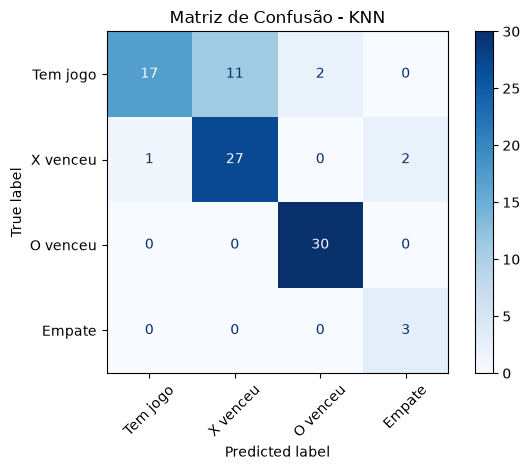

In [39]:
resultados_validacao = executar()

### 4.2 Comparação das métricas na validação

Foram comparadas as métricas de acurácia, precisão, recall e F1 macro das duas abordagens, utilizando o melhor valor de K de cada uma.

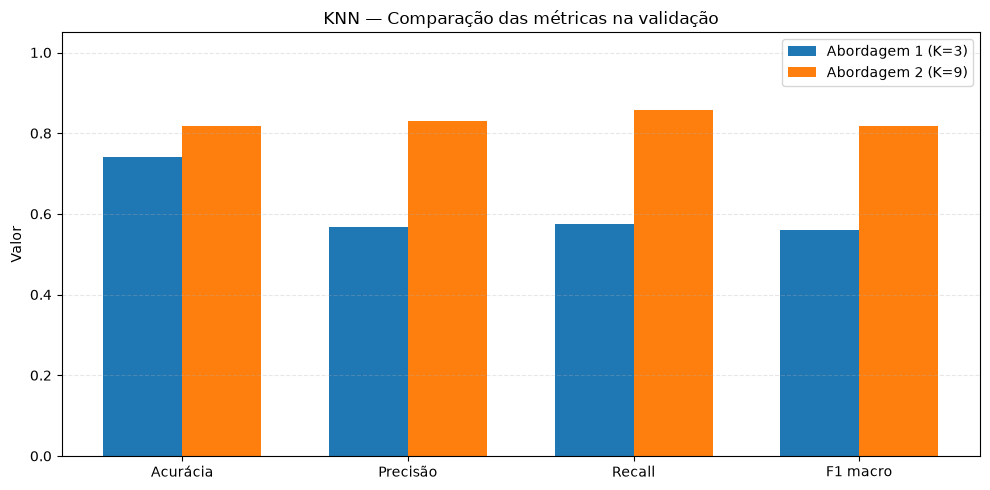

In [40]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Resultados de todas as configuracoes testadas
df = pd.DataFrame(resultados_validacao)

# Seleciona o melhor K de cada abordagem pelo F1 macro
melhores = df.loc[
    df.groupby("abordagem")["f1"].idxmax()
].sort_values("abordagem")

metricas = ["acuracia", "precisao", "recall", "f1"]
nomes = ["Acurácia", "Precisão", "Recall", "F1 macro"]

x = np.arange(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, (_, linha) in enumerate(melhores.iterrows()):
    valores = [linha[metrica] for metrica in metricas]

    ax.bar(
        x + (i - 0.5) * largura,
        valores,
        largura,
        label=f"Abordagem {i + 1} (K={int(linha['k'])})"
    )

ax.set_title("KNN — Comparação das métricas na validação")
ax.set_ylabel("Valor")
ax.set_xticks(x)
ax.set_xticklabels(nomes)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("knn_metricas_validacao.png", dpi=300)
plt.show()



A Abordagem 2 apresentou resultados superiores em todas as métricas avaliadas, utilizando K = 9. Já a Abordagem 1 obteve seu melhor resultado com K = 3. Isso indica que a segunda representação dos dados foi mais eficiente para o KNN.

### 4.3 Análise de overfitting

Para investigar possíveis sinais de overfitting, foi realizada uma comparação do desempenho do KNN nos conjuntos de treinamento, validação e teste.

Foi utilizada a melhor configuração identificada anteriormente: **Abordagem 2, com K = 9**.

O modelo foi treinado com os dados de treinamento e, em seguida, avaliado nos três conjuntos utilizando a métrica F1 macro.

O objetivo dessa comparação é verificar se o desempenho no treinamento é significativamente superior ao observado nos dados de validação e teste, o que poderia indicar dificuldades de generalização.

Como o conjunto de treinamento passou por oversampling, seus resultados devem ser interpretados considerando a repetição de exemplos da classe minoritária.

In [43]:

# Comparação entre treinamento, validação e teste
treino, validacao, teste = carregar_dados("abordagem_2")

X_treino, y_treino = separar_dados(treino)
X_validacao, y_validacao = separar_dados(validacao)
X_teste, y_teste = separar_dados(teste)

modelo = criar_modelo(9)
modelo.fit(X_treino, y_treino)

for nome, X, y in [
    ("Treinamento", X_treino, y_treino),
    ("Validação", X_validacao, y_validacao),
    ("Teste", X_teste, y_teste),
]:
    previsoes = modelo.predict(X)
    resultado = f1_score(
        y, previsoes, average="macro", zero_division=0
    )
    print(f"{nome}: F1 macro = {resultado:.4f}")



Treinamento: F1 macro = 0.8957
Validação: F1 macro = 0.8168
Teste: F1 macro = 0.8050


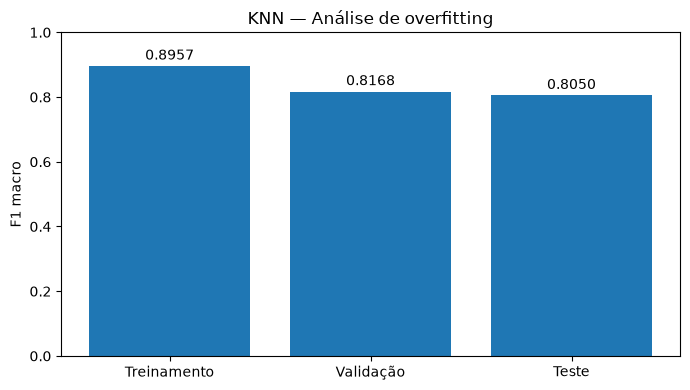

In [42]:
import matplotlib.pyplot as plt

conjuntos = ["Treinamento", "Validação", "Teste"]
f1 = [0.8957, 0.8168, 0.8050]

plt.figure(figsize=(7, 4))
barras = plt.bar(conjuntos, f1)

plt.title("KNN — Análise de overfitting")
plt.ylabel("F1 macro")
plt.ylim(0, 1)

for barra, valor in zip(barras, f1):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig("knn_overfitting.png", dpi=300)
plt.show()

### Interpretação dos resultados de overfitting

O KNN apresentou F1 macro de 0,8957 no treinamento, 0,8168 na validação e 0,8050 no teste.

O desempenho superior no treinamento indica uma possível tendência ao overfitting, uma vez que o modelo apresentou resultados inferiores nos conjuntos não utilizados durante o aprendizado.

Entretanto, os resultados de validação e teste foram relativamente próximos, sugerindo que o modelo manteve um desempenho semelhante nos dados não utilizados no treinamento.

É importante considerar que o conjunto de treinamento passou por oversampling, com repetição de exemplos da classe minoritária, o que também pode influenciar a diferença observada.

Portanto, embora não seja possível descartar completamente o overfitting, os resultados indicam uma capacidade razoável de generalização para os conjuntos avaliados.   

## 4. Resultados dos experimentos

### 4.1 Comparação entre as abordagens

O algoritmo KNN foi avaliado nas duas abordagens de representação dos tabuleiros, utilizando oito valores diferentes de K. O desempenho foi medido pelo F1 macro no conjunto de validação.

| Valor de K | Abordagem 1 | Abordagem 2 |
|---|---:|---:|
| 1 | 0,5370 | 0,7637 |
| 3 | 0,5603 | 0,7906 |
| 5 | 0,5140 | 0,7905 |
| 7 | 0,5507 | 0,8000 |
| 9 | 0,5285 | **0,8168** |
| 11 | 0,5220 | 0,7791 |
| 15 | 0,4819 | 0,7998 |
| 21 | 0,4413 | 0,7693 |

A Abordagem 2 apresentou resultados superiores em todos os valores de K testados.

Na Abordagem 1, o melhor resultado foi obtido com K = 3, alcançando F1 macro de 0,5603. Já na Abordagem 2, o melhor resultado foi obtido com K = 9, alcançando F1 macro de 0,8168.

Dessa forma, selecionamos a Abordagem 2 com K = 9 para a avaliação final no conjunto de teste.

### 4.2 Gráfico comparativo






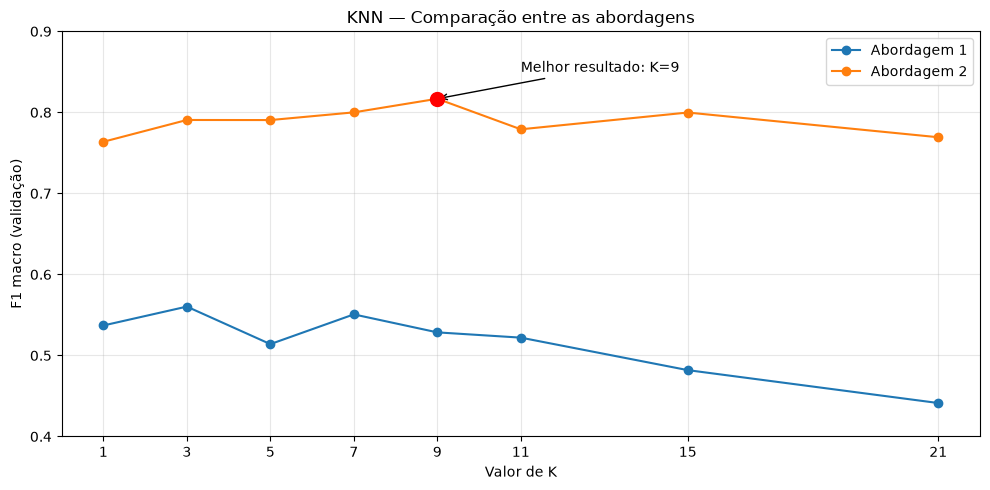

In [38]:
import matplotlib.pyplot as plt

# Valores de K testados
valores_k = [1, 3, 5, 7, 9, 11, 15, 21]

# Resultados do F1 macro na validação
abordagem_1 = [0.5370, 0.5603, 0.5140, 0.5507, 0.5285, 0.5220, 0.4819, 0.4413]
abordagem_2 = [0.7637, 0.7906, 0.7905, 0.8000, 0.8168, 0.7791, 0.7998, 0.7693]

plt.figure(figsize=(10, 5))

plt.plot(valores_k, abordagem_1, marker="o", label="Abordagem 1")
plt.plot(valores_k, abordagem_2, marker="o", label="Abordagem 2")

# Destacar a melhor configuração
plt.scatter(9, 0.8168, color="red", s=100, zorder=5)
plt.annotate(
    "Melhor resultado: K=9",
    xy=(9, 0.8168),
    xytext=(11, 0.85),
    arrowprops=dict(arrowstyle="->"),
)

plt.title("KNN — Comparação entre as abordagens")
plt.xlabel("Valor de K")
plt.ylabel("F1 macro (validação)")
plt.xticks(valores_k)
plt.ylim(0.4, 0.9)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("knn_comparacao_abordagens.png", dpi=300)
plt.show()

### 4.3 Avaliação no conjunto de teste

Após a escolha da melhor configuração com base nos resultados da validação, avaliamos o KNN utilizando a Abordagem 2 e K = 9 no conjunto de teste.

Os resultados obtidos foram:

| Métrica | Resultado |
|---|---|
| Acurácia | 0,8280 (82,80%) |
| Precisão macro | 0,7981 |
| Recall macro | 0,8667 |
| F1 macro | 0,8050 |

O modelo classificou corretamente 77 dos 93 tabuleiros presentes no conjunto de teste.

### 4.4 Análise dos resultados

O KNN apresentou melhor desempenho utilizando a Abordagem 2, que representa o tabuleiro por meio de características calculadas a partir do estado do jogo.

Na avaliação por classe, observamos que o algoritmo conseguiu identificar corretamente todos os 30 exemplos de vitória de O presentes no teste. Para a classe de vitória de X, identificou corretamente 27 dos 30 exemplos.

A maior dificuldade ocorreu na classe "Tem jogo", em que apenas 17 dos 30 tabuleiros foram classificados corretamente. Isso indica que o modelo ainda apresenta dificuldades para diferenciar algumas partidas em andamento de situações em que já existe um vencedor.

Essa dificuldade é especialmente relevante para a integração com o frontend, pois uma classificação incorreta de uma partida em andamento como encerrada pode provocar a interrupção prematura do jogo. Por esse motivo, será importante avaliar o comportamento do KNN durante partidas interativas, além dos resultados obtidos no conjunto de teste.

Os três exemplos de empate foram classificados corretamente. Entretanto, como essa classe possui poucos registros no conjunto de teste, esse resultado não é suficiente para afirmar que o modelo terá o mesmo desempenho em uma quantidade maior de exemplos.

De modo geral, os resultados indicam que a utilização de características derivadas do tabuleiro favoreceu o desempenho do KNN neste experimento.
## 5. Conclusão

Entre as configurações avaliadas, o KNN apresentou seu melhor desempenho utilizando a Abordagem 2, com 15 características derivadas do tabuleiro e K = 9. Essa configuração alcançou F1 macro de 0,8168 no conjunto de validação.

Na avaliação final, o modelo obteve **82,80% de acurácia e F1 macro de 0,8050** no conjunto de teste, classificando corretamente 77 dos 93 tabuleiros avaliados.

Na análise de overfitting, foram obtidos valores de F1 macro de 0,8957 no treinamento, 0,8168 na validação e 0,8050 no teste. Embora o desempenho superior no treinamento indique uma possível tendência ao overfitting, a proximidade entre os resultados de validação e teste sugere uma capacidade razoável de generalização para os dados avaliados.

A principal dificuldade do algoritmo ocorreu na identificação de partidas ainda em andamento, enquanto os resultados para as classes de vitória foram mais satisfatórios. Além disso, a pequena quantidade de exemplos de empate no conjunto de teste limita a avaliação dessa classe.

De modo geral, a Abordagem 2 apresentou resultados superiores à Abordagem 1, indicando que a utilização de características derivadas do tabuleiro favoreceu o desempenho do KNN.

Os resultados obtidos serão utilizados na comparação com os demais classificadores desenvolvidos pelo grupo, a fim de identificar o algoritmo mais adequado para a classificação dos estados do Jogo da Velha.